**IMPORT LIBRARY**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

**LOAD DATASET**

In [ ]:
transactions = pd.read_csv('/content/drive/MyDrive/Sistem Rekomendasi/ecommerce_products.csv')
products = pd.read_csv('/content/drive/MyDrive/Sistem Rekomendasi/ecommerce_transactions.csv')
transactions.head()

,product_id,product_name,category,price,stock
0,1,Electronics Product 1,Electronics,245.75,333
1,2,Books Product 2,Books,362.52,139
2,3,Fashion Product 3,Fashion,11.04,124
3,4,Books Product 4,Books,348.50,301
4,5,Books Product 5,Books,359.51,292


**Exploratory Data Analysis**

In [ ]:
print(transactions.shape)
print(transactions.info())
print(transactions.describe())

(300, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    300 non-null    int64  
 1   product_name  300 non-null    object 
 2   category      300 non-null    object 
 3   price         300 non-null    float64
 4   stock         300 non-null    int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 11.8+ KB
None
       product_id       price       stock
count  300.000000  300.000000  300.000000
mean   150.500000  260.603467  246.583333
std     86.746758  149.770597  135.674494
min      1.000000    6.160000   10.000000
25%     75.750000  127.230000  130.500000
50%    150.500000  276.215000  258.500000
75%    225.250000  396.980000  355.000000
max    300.000000  499.680000  498.000000


**Visualisasi Distribusi Rating**

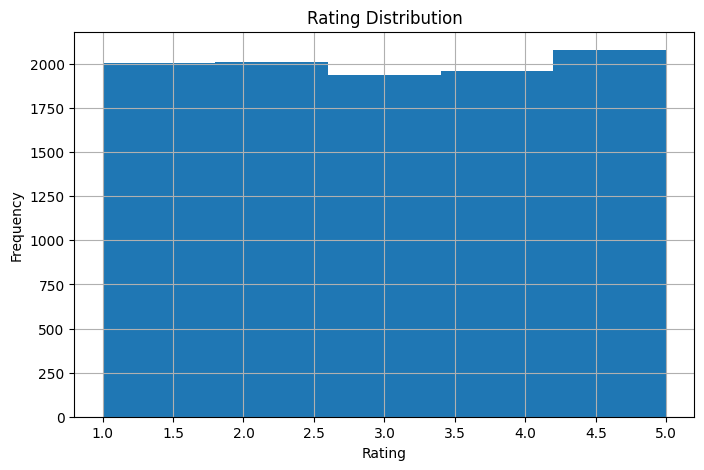

In [ ]:
# Distribusi Rating
plt.figure(figsize=(8,5))
products['rating'].hist(bins=5)
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Rating Distribution')
plt.show()

**Membuat User-Item Matrix**

In [ ]:
# Membuat User-Item Matrix
user_item_matrix = products.pivot_table(
    index='user_id',
    columns='product_id',
    values='rating'
)
user_item_matrix.head()

product_id,1,2,3,4,5,6,7,8,9,10,...,291,292,293,294,295,296,297,298,299,300
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Mengisi Missing Value & Inisialisasi Parameter PMF**

In [ ]:
# Mengisi Missing Value
ratings = user_item_matrix.fillna(0).values
num_users, num_items = ratings.shape

print("Users:", num_users)
print("Items:", num_items)

# Keterangan Parameter
K = 20                 # jumlah latent factor
learning_rate = 0.01   # kecepatan training
regularization = 0.1   # mencegah overfitting
epochs = 50

# Inisialisasi Latent Matrix
scale = 1. / K
U = np.random.normal(scale=scale, size=(num_users, K))
V = np.random.normal(scale=scale, size=(num_items, K))

Users: 1000
Items: 300


**Proses Training PMF (Gradient Descent)**

In [ ]:
# Training PMF dengan Gradient Descent Optimization
training_process = []

for epoch in range(epochs):
    for i in range(num_users):
        for j in range(num_items):
            if ratings[i, j] > 0:
                # Predict rating
                prediction = np.dot(U[i, :], V[j, :].T)

                # Calculate error
                error = ratings[i, j] - prediction

                # Update user and item latent matrices
                U[i, :] += learning_rate * (error * V[j, :] - regularization * U[i, :])
                V[j, :] += learning_rate * (error * U[i, :] - regularization * V[j, :])

    # Compute loss / RMSE untuk epoch saat ini
    predicted_matrix = np.dot(U, V.T)
    mask = ratings > 0
    rmse = sqrt(mean_squared_error(ratings[mask], predicted_matrix[mask]))
    training_process.append(rmse)

    print(f"Epoch {epoch+1}/{epochs}, RMSE: {rmse:.4f}")

Epoch 1/50, RMSE: 3.3237
Epoch 2/50, RMSE: 3.3198
Epoch 3/50, RMSE: 3.3143
Epoch 4/50, RMSE: 3.3051
Epoch 5/50, RMSE: 3.2871
Epoch 6/50, RMSE: 3.2474
Epoch 7/50, RMSE: 3.1531
Epoch 8/50, RMSE: 2.9348
Epoch 9/50, RMSE: 2.5162
Epoch 10/50, RMSE: 1.9740
Epoch 11/50, RMSE: 1.5584
Epoch 12/50, RMSE: 1.3519
Epoch 13/50, RMSE: 1.2598
Epoch 14/50, RMSE: 1.2106
Epoch 15/50, RMSE: 1.1769
Epoch 16/50, RMSE: 1.1490
Epoch 17/50, RMSE: 1.1230
Epoch 18/50, RMSE: 1.0973
Epoch 19/50, RMSE: 1.0713
Epoch 20/50, RMSE: 1.0447
Epoch 21/50, RMSE: 1.0175
Epoch 22/50, RMSE: 0.9898
Epoch 23/50, RMSE: 0.9616
Epoch 24/50, RMSE: 0.9333
Epoch 25/50, RMSE: 0.9049
Epoch 26/50, RMSE: 0.8768
Epoch 27/50, RMSE: 0.8491
Epoch 28/50, RMSE: 0.8220
Epoch 29/50, RMSE: 0.7956
Epoch 30/50, RMSE: 0.7701
Epoch 31/50, RMSE: 0.7457
Epoch 32/50, RMSE: 0.7223
Epoch 33/50, RMSE: 0.7000
Epoch 34/50, RMSE: 0.6788
Epoch 35/50, RMSE: 0.6588
Epoch 36/50, RMSE: 0.6399
Epoch 37/50, RMSE: 0.6220
Epoch 38/50, RMSE: 0.6053
Epoch 39/50, RMSE: 0.

**Visualisasi Performa Training**

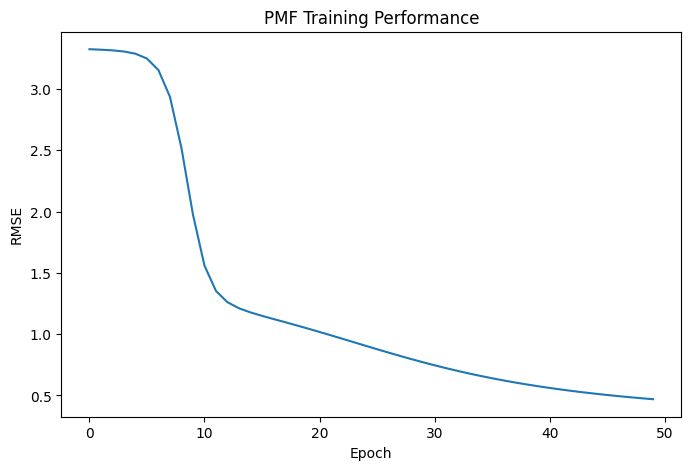

In [ ]:
# Training Visualization
plt.figure(figsize=(8,5))
plt.plot(training_process)
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('PMF Training Performance')
plt.show()

**Membuat Predicted Rating Matrix & Cek Prediksi Spesifik**

In [ ]:
# Predicted Rating Matrix
predicted_ratings = np.dot(U, V.T)
print(predicted_ratings)

# Cek Prediksi Rating untuk User 1 dan Produk 10
user_id = 1
product_id = 10

predicted_score = predicted_ratings[user_id-1, product_id-1]
print("Predicted Rating:", round(predicted_score, 3))

[[2.29661543 3.47542943 2.60411349 ... 3.04941344 3.48107234 3.20734943]
 [1.37762867 2.82451385 1.80677729 ... 1.27432711 1.86919245 1.72257292]
 [2.46835562 3.82366994 2.45978903 ... 2.93054342 3.54016775 2.5080214 ]
 ...
 [2.28334645 3.00054965 1.86436612 ... 1.33504933 1.90185809 2.25825702]
 [1.61680048 3.50776071 2.66222636 ... 2.34171996 3.1611103  2.36763274]
 [2.00755935 3.12348142 2.06835927 ... 2.2372569  2.89407354 1.49611835]]
Predicted Rating: 2.443


**Rekomendasi Top-N untuk User Spesifik**

In [ ]:
# Top-N Recommendation untuk User 5
user_id = 5

user_predictions = predicted_ratings[user_id-1]
top_items = np.argsort(user_predictions)[::-1][:10]

recommendations = []
for item_index in top_items:
    product_id = user_item_matrix.columns[item_index]
    score = user_predictions[item_index]
    recommendations.append((product_id, score))

# Menampilkan Nama Produk Hasil Rekomendasi
print(f"Top 10 Recommendations for User {user_id}:\n")
for product_id, score in recommendations:
    product_name = transactions[transactions['product_id'] == product_id]['product_name'].values[0]
    print(f"{product_name} Score: {round(score, 2)}")

Top 10 Recommendations for User 5:

Electronics Product 237 Score: 4.8
Sports Product 182 Score: 4.44
Fashion Product 294 Score: 4.08
Books Product 220 Score: 4.08
Home Product 147 Score: 4.05
Sports Product 258 Score: 4.0
Fashion Product 15 Score: 3.93
Beauty Product 285 Score: 3.92
Beauty Product 249 Score: 3.87
Fashion Product 255 Score: 3.79


**Visualisasi Hasil Rekomendasi (Bar Chart)**

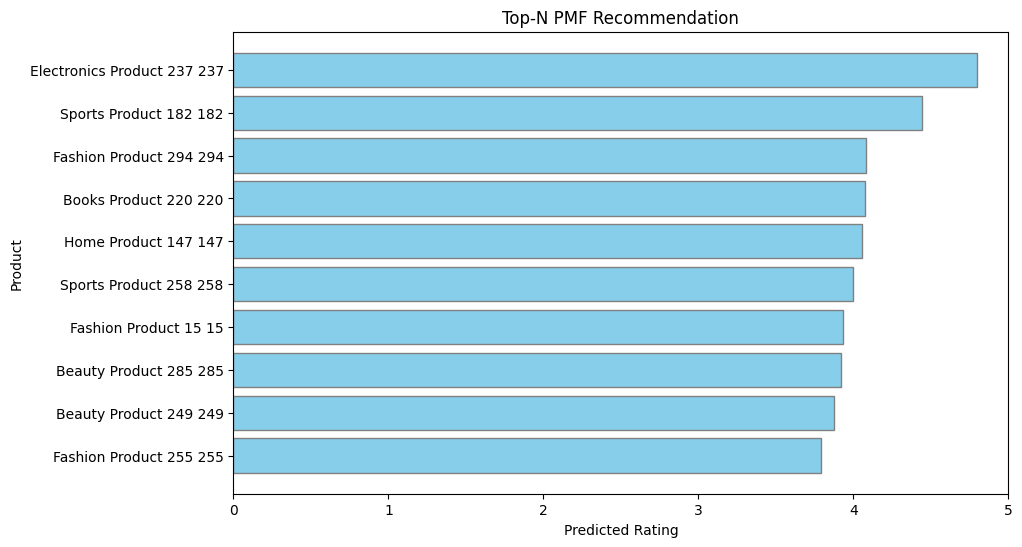

In [ ]:
# Visualisasi Recommendation
product_names = []
scores = []

for product_id, score in recommendations:
    product_name = transactions[transactions['product_id'] == product_id]['product_name'].values[0]
    product_names.append(f"{product_name} {product_id}")
    scores.append(score)

# Membalik urutan agar score tertinggi berada di paling atas pada horizontal bar chart
product_names.reverse()
scores.reverse()

plt.figure(figsize=(10, 6))
plt.barh(product_names, scores, color='skyblue', edgecolor='gray')
plt.xlabel('Predicted Rating')
plt.ylabel('Product')
plt.title('Top-N PMF Recommendation')
plt.xlim(0, 5) # Batas rating 0-5
plt.show()